# Ames Housing, Solution Achieves Top 8% on Public Leaderboard at Time of Writing
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview

### Import Packages and Data, Surface Level Analysis

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import RandomSampler, TPESampler
from catboost import CatBoostRegressor, Pool, cv
import lightgbm as lgb
import xgboost as xgb
from pathlib import Path
import os

SEED = 99
np.random.seed(SEED)

In [3]:
data_dir = Path.cwd().parent / "Data"

train = pd.read_csv(data_dir / "train.csv")
train["Dataset"] = "Train"

test = pd.read_csv(data_dir / "test.csv")
test["Dataset"] = "Test"

comb = pd.concat([train.drop("SalePrice", axis=1), test], axis=0).reset_index(drop=True)

In [4]:
pd.set_option("display.max_rows", 90)

comb.isna().sum()

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
Alley            2721
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType       1766
MasVnrArea         23
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           81
BsmtCond           82
BsmtExposure       82
BsmtFinType1       79
BsmtFinSF1          1
BsmtFinType2       80
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

Nulls look pretty easy to deal with to be honest. A lot of the nulls seem to just be if the house doesn't have that particular feature so not much of a worry there, the other factors just seem like freak 1/2 missings which are fairly easily dealt with.

In [5]:
y_train = train["SalePrice"]

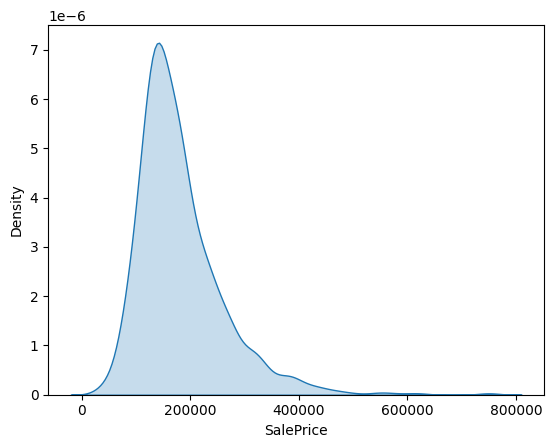

Raw Target Vairable Skew: 1.88


In [6]:
sns.kdeplot(y_train, fill=True)
plt.show()

print(f"Raw Target Vairable Skew: {np.round(y_train.skew(), 2)}")

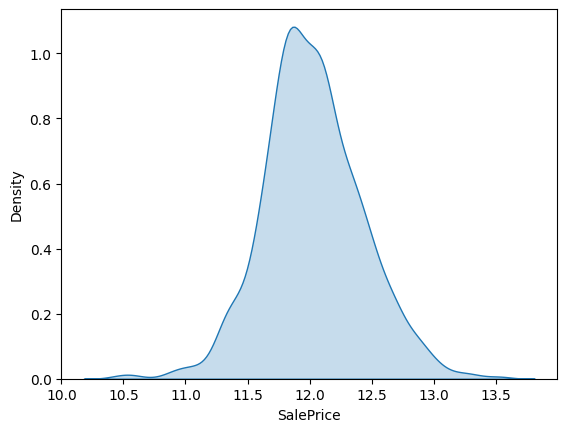

Logged Target Vairable Skew: 0.12


In [7]:
sns.kdeplot(np.log(y_train), fill=True)
plt.show()

print(f"Logged Target Vairable Skew: {np.round(np.log(y_train).skew(), 2)}")

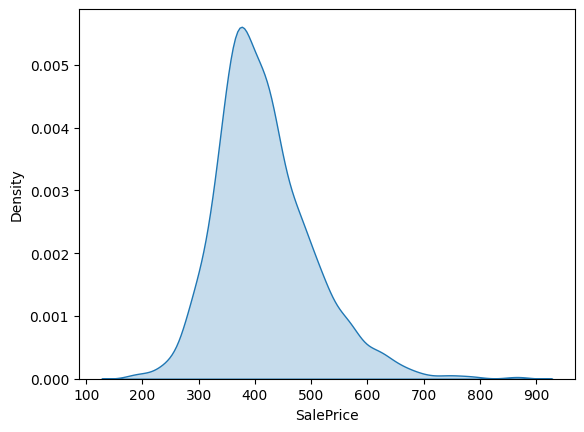

Rooted Target Vairable Skew: 0.94


In [8]:
sns.kdeplot(np.sqrt(y_train), fill=True)
plt.show()

print(f"Rooted Target Vairable Skew: {np.round(np.sqrt(y_train).skew(), 2)}")

Target variable has a significant positive skew, looking at potential transformations, logging it gives a more unskewed result compared to square rooting. Logged sale price will be the target variable we try to predict!

In [9]:
y_train = np.log(train["SalePrice"])

### Null Handling

In [10]:
nulls_df = pd.DataFrame(comb.isna().sum()).reset_index()
nulls_df.columns = ["Variable", "NullCount"]

nulls_df[nulls_df["NullCount"]>0].sort_values("NullCount", ascending=False)

,Variable,NullCount
72,PoolQC,2909
74,MiscFeature,2814
6,Alley,2721
73,Fence,2348
25,MasVnrType,1766
57,FireplaceQu,1420
3,LotFrontage,486
60,GarageFinish,159
63,GarageQual,159
64,GarageCond,159


Find and fix incongruencies, make binary flags where needed

PoolQC

In [11]:
comb[~comb["PoolQC"].isna()]["PoolArea"]

197     512
810     648
1170    576
1182    555
1298    480
1386    519
1423    738
1974    144
2573    228
2710    800
Name: PoolArea, dtype: int64

In [12]:
m1 = comb["PoolArea"]>0
m2 = comb["PoolQC"].isna()

comb[(m1)&(m2)]["PoolArea"]

2420    368
2503    444
2599    561
Name: PoolArea, dtype: int64

In [13]:
comb["PoolFlag"] = (comb["PoolArea"]>0).astype(int)

Misc feature

In [14]:
comb[["MiscFeature", "MiscVal"]][(comb["MiscFeature"].isna()) & (comb["MiscVal"]>0)]

,MiscFeature,MiscVal
2549,NaN,17000


In [15]:
comb["MiscFeature"] = np.where((comb["MiscFeature"].isna()) & (comb["MiscVal"]>0), "Othr", comb["MiscFeature"])
comb["MiscFeatureFlag"] = (comb["MiscFeature"].notna()).astype(int)

Alley

In [16]:
comb["AlleyFlag"] = (comb["Alley"].notna()).astype(int)

Fence

In [17]:
comb["FenceFlag"] = (comb["Fence"].notna()).astype(int)

MasVnrType

In [18]:
m1 = comb["MasVnrType"].isna()
m2 = comb["MasVnrArea"]>0

comb[(m1)&(m2)][["MasVnrType", "MasVnrArea", "Neighborhood"]]

,MasVnrType,MasVnrArea,Neighborhood
624,NaN,288.0,NWAmes
773,NaN,1.0,NAmes
1230,NaN,1.0,Sawyer
1300,NaN,344.0,Gilbert
1334,NaN,312.0,BrDale
1669,NaN,285.0,NridgHt
2452,NaN,1.0,OldTown
2610,NaN,198.0,Mitchel


In [19]:
# 1s look like a mistake, there are no 1s with filled types, lets keep type as na here and revert to 0 area so we don't trip our models up

comb["MasVnrArea"] = np.where((comb["MasVnrArea"]==1) & (comb["MasVnrType"].isna()), 0, comb["MasVnrArea"])

In [20]:
modal_dict = comb[comb["MasVnrArea"]>0].groupby("Neighborhood")["MasVnrType"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).to_dict()

comb["MasVnrType"] = np.where((comb["MasVnrArea"]>0) & (comb["MasVnrType"].isna()), comb["Neighborhood"].map(modal_dict), comb["MasVnrType"])

In [21]:
m1 = comb["MasVnrType"].notna()
m2 = comb["MasVnrArea"]==0

comb[(m1)&(m2)][["MasVnrType", "MasVnrArea"]]

,MasVnrType,MasVnrArea
688,BrkFace,0.0
1241,Stone,0.0
2319,BrkFace,0.0


In [22]:
comb["MasVnrType"].isna().sum()

np.int64(1761)

In [23]:
comb["MasVnrType"] = np.where((comb["MasVnrType"].notna()) & (comb["MasVnrArea"]==0), np.nan, comb["MasVnrType"])
comb["MasVnrFlag"] = (comb["MasVnrArea"]>0).astype(int)

FireplaceQu

In [24]:
m1 = comb["FireplaceQu"].isna()
m2 = comb["Fireplaces"]>0

comb[(m1) & (m2)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,Dataset,PoolFlag,MiscFeatureFlag,AlleyFlag,FenceFlag,MasVnrFlag


In [25]:
comb["FireplaceFlag"] = (comb["Fireplaces"]>0).astype(int)

LotFrontage

In [26]:
comb["NoFrontageFlag"] = (comb["LotFrontage"].isna()).astype(int)

Garage

In [27]:
m1 = comb["GarageFinish"].isna()
m2 = comb["GarageType"].notna()

comb[(m1)&(m2)][[i for i in comb.columns if "Garage" in i]+["YearBuilt"]]

,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,YearBuilt
2126,Detchd,NaN,NaN,1.0,360.0,NaN,NaN,1910
2576,Detchd,NaN,NaN,NaN,NaN,NaN,NaN,1923


In [28]:
# Interesting! One garage with a one car capacity and 360 area, one with no other info. I will call the slightly populated one real, and the completely blank one not real and adjust accordingly
comb.iloc[2576, comb.columns.get_loc("GarageCars")] = 0
comb.iloc[2576, comb.columns.get_loc("GarageArea")] = 0
comb.iloc[2576, comb.columns.get_loc("GarageType")] = np.nan

comb.iloc[2126, comb.columns.get_loc("GarageYrBlt")] = comb.iloc[2126]["YearBuilt"]
comb.iloc[2126, comb.columns.get_loc("GarageQual")] = "TA"
comb.iloc[2126, comb.columns.get_loc("GarageCond")] = "TA"
comb.iloc[2126, comb.columns.get_loc("GarageFinish")] = "Unf"

In [29]:
comb["NoGarageFlag"] = (comb["GarageArea"]==0).astype(int)

In [30]:
# A quick check that all 158 garage nulls now match up row-wise

cols = ["GarageFinish", "GarageQual", "GarageCond", "GarageYrBlt", "GarageType"]
null_df = comb[cols].isna()

all_equal = null_df.nunique(axis=1).eq(1).all()
all_equal

np.True_

Basement

In [31]:
basement_vars = [i for i in comb.columns if "Bsmt" in i]

basement_vars

['BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'BsmtFullBath',
 'BsmtHalfBath']

In [32]:
m1 = comb["BsmtQual"].isna()
m2 = comb["TotalBsmtSF"]>0

comb[(m1) & (m2)][basement_vars]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
2217,NaN,Fa,No,Unf,0.0,Unf,0.0,173.0,173.0,0.0,0.0
2218,NaN,TA,No,Unf,0.0,Unf,0.0,356.0,356.0,0.0,0.0


In [33]:
# Lets impute avg BsmtQual by neighborhood

modal_dict = comb[comb["TotalBsmtSF"]>0].groupby("Neighborhood")["BsmtQual"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).to_dict()

comb["BsmtQual"] = np.where((comb["TotalBsmtSF"]>0) & (comb["BsmtQual"].isna()), comb["Neighborhood"].map(modal_dict), comb["BsmtQual"])

In [34]:
m1 = comb["BsmtQual"].notna()
m2 = comb["BsmtCond"].isna()

comb[(m1) & (m2)][basement_vars]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
2040,Gd,NaN,Mn,GLQ,1044.0,Rec,382.0,0.0,1426.0,1.0,0.0
2185,TA,NaN,No,BLQ,1033.0,Unf,0.0,94.0,1127.0,0.0,1.0
2524,TA,NaN,Av,ALQ,755.0,Unf,0.0,240.0,995.0,0.0,0.0


In [35]:
# Lets impute avg BsmtCond by neighborhood

modal_dict = comb[comb["BsmtCond"].notna()].groupby("Neighborhood")["BsmtCond"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).to_dict()

comb["BsmtCond"] = np.where((comb["BsmtQual"].notna()) & (comb["BsmtCond"].isna()), comb["Neighborhood"].map(modal_dict), comb["BsmtCond"])

In [36]:
m1 = comb["BsmtQual"].notna()
m2 = comb["BsmtExposure"].isna()

comb[(m1) & (m2)][basement_vars]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
948,Gd,TA,NaN,Unf,0.0,Unf,0.0,936.0,936.0,0.0,0.0
1487,Gd,TA,NaN,Unf,0.0,Unf,0.0,1595.0,1595.0,0.0,0.0
2348,Gd,TA,NaN,Unf,0.0,Unf,0.0,725.0,725.0,0.0,0.0


In [37]:
exp_ids = list(comb[(m1) & (m2)][basement_vars].index)
comb.loc[exp_ids, "BsmtExposure"] = "No"

In [38]:
m1 = comb["BsmtQual"].notna()
m2 = comb["BsmtFinType2"].isna()

comb[(m1) & (m2)][basement_vars]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
332,Gd,TA,No,GLQ,1124.0,NaN,479.0,1603.0,3206.0,1.0,0.0


In [39]:
comb.loc[332, "BsmtFinType2"] = "GLQ"

In [40]:
# A quick check that all 158 garage nulls now match up row-wise

cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
null_df = comb[cols].isna()

all_equal = null_df.nunique(axis=1).eq(1).all()
all_equal

np.True_

In [41]:
comb.iloc[2120]

Id                    2121
MSSubClass              20
MSZoning                RM
LotFrontage           99.0
LotArea               5940
Street                Pave
Alley                  NaN
LotShape               IR1
LandContour            Lvl
Utilities           AllPub
LotConfig              FR3
LandSlope              Gtl
Neighborhood       BrkSide
Condition1           Feedr
Condition2            Norm
BldgType              1Fam
HouseStyle          1Story
OverallQual              4
OverallCond              7
YearBuilt             1946
YearRemodAdd          1950
RoofStyle            Gable
RoofMatl           CompShg
Exterior1st        MetalSd
Exterior2nd         CBlock
MasVnrType             NaN
MasVnrArea             0.0
ExterQual               TA
ExterCond               TA
Foundation           PConc
BsmtQual               NaN
BsmtCond               NaN
BsmtExposure           NaN
BsmtFinType1           NaN
BsmtFinSF1             NaN
BsmtFinType2           NaN
BsmtFinSF2             NaN
B

In [42]:
comb.loc[2120, "BsmtFinSF1"] = 0
comb.loc[2120, "BsmtFinSF2"] = 0
comb.loc[2120, "BsmtUnfSF"] = 0
comb.loc[2120, "TotalBsmtSF"] = 0
comb.loc[2120, "BsmtFullBath"] = 0
comb.loc[2120, "BsmtHalfBath"] = 0

In [43]:
comb.iloc[2120][[i for i in comb.columns if "Bsmt" in i]]

BsmtQual        NaN
BsmtCond        NaN
BsmtExposure    NaN
BsmtFinType1    NaN
BsmtFinSF1      0.0
BsmtFinType2    NaN
BsmtFinSF2      0.0
BsmtUnfSF       0.0
TotalBsmtSF     0.0
BsmtFullBath    0.0
BsmtHalfBath    0.0
Name: 2120, dtype: object

In [44]:
comb[comb["BsmtHalfBath"].isna()][[i for i in comb.columns if "Bsmt" in i]]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
2188,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN


In [45]:
comb.loc[2188, "BsmtFullBath"] = 0
comb.loc[2188, "BsmtHalfBath"] = 0

In [46]:
comb["NoBasementFlag"] = (comb["BsmtQual"].isna()).astype(int)

In [47]:
nulls_df = pd.DataFrame(comb.isna().sum()).reset_index()
nulls_df.columns = ["Variable", "NullCount"]

nulls_df[nulls_df["NullCount"]>0].sort_values("NullCount", ascending=False)

,Variable,NullCount
72,PoolQC,2909
74,MiscFeature,2813
6,Alley,2721
73,Fence,2348
25,MasVnrType,1764
57,FireplaceQu,1420
3,LotFrontage,486
63,GarageQual,158
60,GarageFinish,158
59,GarageYrBlt,158


MasVnrArea

In [48]:
comb[comb["MasVnrArea"].isna()]["MasVnrType"]

234     NaN
529     NaN
650     NaN
936     NaN
973     NaN
977     NaN
1243    NaN
1278    NaN
1691    NaN
1706    NaN
1882    NaN
1992    NaN
2004    NaN
2041    NaN
2311    NaN
2325    NaN
2340    NaN
2349    NaN
2368    NaN
2592    NaN
2657    NaN
2686    NaN
2862    NaN
Name: MasVnrType, dtype: object

In [49]:
comb["MasVnrArea"] = comb["MasVnrArea"].fillna(0)

MSZoning

In [50]:
comb["MSZoning"].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

In [51]:
comb["MSZoning"] = comb["MSZoning"].fillna("RL")

Functional

In [52]:
comb["Functional"].value_counts()

Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64

In [53]:
comb["Functional"] = comb["Functional"].fillna("Typ")

Utilities

In [54]:
comb["Utilities"].value_counts()

Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64

In [55]:
comb["Utilities"] = comb["Utilities"].fillna("AllPub")

Electrical

In [56]:
comb["Electrical"].value_counts()

Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [57]:
comb["Electrical"] = comb["Electrical"].fillna("SBrkr")

Exterior

In [58]:
comb[comb["Exterior2nd"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Dataset,PoolFlag,MiscFeatureFlag,AlleyFlag,FenceFlag,MasVnrFlag,FireplaceFlag,NoFrontageFlag,NoGarageFlag,NoBasementFlag
2151,2152,30,RL,85.0,19550,Pave,NaN,Reg,Lvl,AllPub,...,Test,0,0,0,0,0,1,0,1,0


In [59]:
comb["Exterior1st"].value_counts()

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

In [60]:
comb.loc[2151, "Exterior1st"] = "VinylSd"
comb.loc[2151, "Exterior2nd"] = "VinylSd"

In [61]:
nulls_df = pd.DataFrame(comb.isna().sum()).reset_index()
nulls_df.columns = ["Variable", "NullCount"]

nulls_df[nulls_df["NullCount"]>0].sort_values("NullCount", ascending=False)

,Variable,NullCount
72,PoolQC,2909
74,MiscFeature,2813
6,Alley,2721
73,Fence,2348
25,MasVnrType,1764
57,FireplaceQu,1420
3,LotFrontage,486
58,GarageType,158
59,GarageYrBlt,158
60,GarageFinish,158


Kitchen

In [62]:
comb["KitchenQual"].value_counts()

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [63]:
comb["KitchenQual"] = comb["KitchenQual"].fillna("TA")

Sale Type

In [64]:
comb["SaleType"].value_counts()

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64

In [65]:
comb["SaleType"] = comb["SaleType"].fillna("WD")

Finally, deal with the ones with masses of nulls

In [66]:
nulls_df = pd.DataFrame(comb.isna().sum()).reset_index()
nulls_df.columns = ["Variable", "NullCount"]

nulls_df[nulls_df["NullCount"]>0].sort_values("NullCount", ascending=False)

,Variable,NullCount
72,PoolQC,2909
74,MiscFeature,2813
6,Alley,2721
73,Fence,2348
25,MasVnrType,1764
57,FireplaceQu,1420
3,LotFrontage,486
58,GarageType,158
59,GarageYrBlt,158
60,GarageFinish,158


In [67]:
null_cat_ords = ["PoolQC", "FireplaceQu", "GarageFinish", "GarageQual", "GarageCond", "BsmtFinType1", "BsmtFinType2", "BsmtExposure", "BsmtCond", "BsmtQual"]
null_cat_noms = ["MiscFeature", "Alley", "Fence", "MasVnrType", "GarageType"]
null_numericals = ["LotFrontage", "GarageYrBlt"]

In [68]:
for i in null_cat_ords:
    comb[i] = comb[i].fillna("NULL")

for i in null_cat_noms:
    comb[i] = comb[i].fillna("NULL")

for i in null_numericals:
    comb[i] = comb[i].fillna(0)

In [69]:
nulls_df = pd.DataFrame(comb.isna().sum()).reset_index()
nulls_df.columns = ["Variable", "NullCount"]

nulls_df[nulls_df["NullCount"]>0].sort_values("NullCount", ascending=False)

,Variable,NullCount


### Feature Engineering

In [70]:
# Find 2nd identifiers for binary flags

[i for i in comb.columns if "2" in i]

['Condition2', 'Exterior2nd', 'BsmtFinType2', 'BsmtFinSF2', '2ndFlrSF']

In [71]:
comb["BsmtFinFlag"] = (comb["BsmtFinSF1"]>0).astype(int)
comb["BsmtFin2Flag"] = (comb["BsmtFinSF2"]>0).astype(int)
comb["2FloorsFlag"] = (comb["2ndFlrSF"]>0).astype(int)

In [72]:
comb["Condition1"].value_counts()

Condition1
Norm      2511
Feedr      164
Artery      92
RRAn        50
PosN        39
RRAe        28
PosA        20
RRNn         9
RRNe         6
Name: count, dtype: int64

In [73]:
comb["Condition2"].value_counts()

Condition2
Norm      2889
Feedr       13
Artery       5
PosN         4
PosA         4
RRNn         2
RRAn         1
RRAe         1
Name: count, dtype: int64

In [74]:
comb["AnyCondFlag"] = (comb["Condition1"]!="Norm").astype(int)
comb["TwoCondFlag"] = (comb["Condition2"]!="Norm").astype(int)

In [75]:
comb[["YearBuilt", "YearRemodAdd"]]

,YearBuilt,YearRemodAdd
0,2003,2003
1,1976,1976
2,2001,2002
3,1915,1970
4,2000,2000
...,...,...
2914,1970,1970
2915,1970,1970
2916,1960,1996
2917,1992,1992


In [76]:
comb["RemodDelta"] = comb["YearRemodAdd"] - comb["YearBuilt"]
comb["RemodDelta"].min()

np.int64(-1)

In [77]:
comb[comb["RemodDelta"]<0][["YearBuilt", "YearRemodAdd"]]

,YearBuilt,YearRemodAdd
1876,2002,2001


In [78]:
comb.iloc[1876, comb.columns.get_loc("YearRemodAdd")] = 2002
comb.iloc[1876, comb.columns.get_loc("RemodDelta")] = 0

In [79]:
comb["RemodFlag"] = (comb["RemodDelta"]>0).astype(int)

In [80]:
comb.iloc[2592, comb.columns.get_loc("GarageYrBlt")] = 2007

In [ ]:
# Make AgeAtSale

comb["AgeAtSale"] = (comb["YrSold"] + round(comb["MoSold"]/12, 0)) - comb["YearBuilt"]
comb["RemodAgeAtSale"] = (comb["YrSold"] + round(comb["MoSold"]/12, 0)) - comb["YearRemodAdd"]
comb["GarageAgeAtSale"] = np.where(comb["GarageYrBlt"]>0, (comb["YrSold"] + round(comb["MoSold"]/12, 0)) - comb["GarageYrBlt"], 0)

In [82]:
# Make outside size and proportion

comb["OutsideSpace"] = comb["LotArea"] - comb["1stFlrSF"]
comb["OutsideProportion"] = comb["OutsideSpace"] / comb["LotArea"]
comb["InsideProportion"] = 1-comb["OutsideProportion"]

In [83]:
# Make completely finished basement flag

comb["CompFinishedBasementFlag"] = ((comb["TotalBsmtSF"]>0) & (comb["BsmtUnfSF"]==0)).astype(int)
comb["BsmtUnFinProp"] = np.where(comb["TotalBsmtSF"]>0, comb["BsmtUnfSF"]/comb["TotalBsmtSF"], 0)
comb["BsmtFinTot"] = comb["TotalBsmtSF"] - comb["BsmtUnfSF"]
comb["BsmtFinProp"] = np.where(comb["TotalBsmtSF"]>0, 1-comb["BsmtUnFinProp"], 0)

In [84]:
# Make total indoor sq footage

comb["TotalIndoorAGSF"] = comb["1stFlrSF"] + comb["2ndFlrSF"]
comb["TotalIndoorHouseSF"] = comb["1stFlrSF"] + comb["2ndFlrSF"] + comb["TotalBsmtSF"]

In [85]:
# Make any low qual from total low qual square footage and proportions thereof

comb["AnyLowQualFlag"] = (comb["LowQualFinSF"]>0).astype(int)
comb["LowQualProp"] = comb["LowQualFinSF"]/comb["TotalIndoorAGSF"]

In [86]:
# Make total bathrooms in basement and above ground, total in house too and proportions above and below ground

comb["BsmtTotBaths"] = comb["BsmtFullBath"]+(0.5*comb["BsmtHalfBath"])
comb["AGTotBaths"] = comb["FullBath"]+(0.5*comb["HalfBath"])
comb["HouseTotBaths"] = comb["BsmtTotBaths"]+comb["AGTotBaths"]
comb["BathsAGProp"] = np.where(comb["HouseTotBaths"]>0, comb["AGTotBaths"]/comb["HouseTotBaths"], 0)
comb["BathsBsmtProp"] = np.where(comb["HouseTotBaths"]>0, 1-comb["BathsAGProp"], 0)
comb["HouseFullBaths"] = comb["FullBath"]+comb["BsmtFullBath"]
comb["HouseHalfBaths"] = comb["HalfBath"]+comb["BsmtHalfBath"]

comb["AnyHalfBathsFlag"] = ((comb["HalfBath"]+comb["BsmtHalfBath"])>0).astype(int)

In [87]:
# Make total rooms inc bathrooms above ground, and square footage per room

comb["TotRmsAbvGrdPBrms"] = comb["TotRmsAbvGrd"]+comb["AGTotBaths"]
comb["SFPerRoom"] = comb["TotalIndoorAGSF"]/comb["TotRmsAbvGrd"]
comb["SFPerRoomPBrms"] = comb["TotalIndoorAGSF"]/comb["TotRmsAbvGrdPBrms"]

In [88]:
# Make any deductions binary

comb["AnyDeductionsFlag"] = (comb["Functional"]!="Typ").astype(int)

In [89]:
# Make garage built after home and garage built delta

comb["GarageBuiltWithHomeFlag"] = (comb["YearBuilt"]==comb["GarageYrBlt"]).astype(int)
comb["GarageBuildDelta"] = np.where((comb["GarageBuiltWithHomeFlag"]==0) & (comb["GarageYrBlt"]>0), comb["GarageYrBlt"]-comb["YearBuilt"], 0)

In [90]:
comb["GarageBuildDelta"].min()

np.float64(-20.0)

In [91]:
# Curious, going to chalk anything with -1 as a little months built quirk where the garage and house build overlappeded a new year, otherwise encode a binary flag

garage_indexes = list(comb[comb["GarageBuildDelta"]==-1].index)
comb.loc[garage_indexes, "GarageYrBlt"] = comb.loc[garage_indexes, "YearBuilt"]
comb.loc[garage_indexes, "GarageBuildDelta"] = 0.0

comb["GarageWayOlderFlag"] = (comb["GarageBuildDelta"]<0).astype(int)

In [92]:
# Oneshot binary targets

binary_targinhos = ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]

name_map = {
    (name[:-2] if name.endswith("SF") else name): name
    for name in binary_targinhos
}

for stripped, original in name_map.items():
    comb[f"{stripped}Flag"] = (comb[original] > 0).astype(int)

In [93]:
# Make total porches and no porch binary

porchflags = [i+"Flag" for i in list(name_map.keys())]

comb["TotPorches"] = comb[porchflags].sum(axis=1)
comb["TotPorchSF"] = comb[binary_targinhos].sum(axis=1)
comb["NoPorchFlag"] = (comb["TotPorches"]==0).astype(int)
comb["GardenSpace"] = comb["OutsideSpace"] - comb["TotPorchSF"]
comb["GardenProp"] = comb["GardenSpace"]/comb["LotArea"]

In [94]:
# Make yearmonth sold, season sold

comb["MonthYearSold"] = comb["MoSold"].astype(str) + "-" + comb["YrSold"].astype(str)

comb["MonthYearSold_dt"] = pd.to_datetime(
    comb["YrSold"].astype(str) + "-" + comb["MoSold"].astype(str) + "-01"
)

def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return None

comb["SeasonSold"] = comb["MoSold"].apply(month_to_season)

comb["MonthYearSoldNum"] = comb["MonthYearSold_dt"].rank(method="dense").astype(int)

comb["YearMonthSold"] = comb["MonthYearSold_dt"].dt.strftime("%Y-%m").astype(str)

In [95]:
monthly_gold = pd.read_csv(data_dir / "monthly_gold.csv")
gold_dict = dict(zip(monthly_gold["Date"], monthly_gold["Price"]))

comb["MonthlyGoldOpen"] = comb["YearMonthSold"].map(gold_dict)

del monthly_gold, gold_dict

In [96]:
monthly_sp500 = pd.read_csv(data_dir / "monthly_sp500.csv")
monthly_sp500["Date"] = pd.to_datetime(monthly_sp500["Date"])
indices_to_fix = range(9, len(monthly_sp500), 12)
monthly_sp500.loc[indices_to_fix, 'Date'] = monthly_sp500.loc[indices_to_fix, 'Date'].apply(
    lambda d: d.replace(month=10)
)
monthly_sp500["YearMonthSold"] = monthly_sp500["Date"].dt.strftime("%Y-%m").astype(str)
sp500_dict = dict(zip(monthly_sp500["YearMonthSold"], monthly_sp500["SP500"]))

comb["MonthlySP500Open"] = comb["YearMonthSold"].map(sp500_dict)

del monthly_sp500, sp500_dict

In [97]:
# Make delta to aggregated average columns function

def median_func(data, agg_column, comp_column):
    group_medians = data.groupby(agg_column)[comp_column].transform("median")
    return data[comp_column] - group_medians

In [98]:
# Make delta to aggregated average columns

agg_cols = ["MSZoning", "LandContour", "LotConfig", "Neighborhood", "BldgType", "HouseStyle", "SaleType"]
comp_cols = ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "TotRmsAbvGrd", "AgeAtSale", "TotalIndoorAGSF", "TotalIndoorHouseSF", "HouseTotBaths", "TotRmsAbvGrdPBrms",
 "SFPerRoomPBrms"]

new_cols = {}

for agg_col in agg_cols:
    for comp_col in comp_cols:
        col_name = f"{comp_col}DeltaFrom{agg_col}Median"
        new_cols[col_name] = median_func(comb, agg_col, comp_col)

comb = comb.assign(**new_cols)

### Data Preprocessing
*"Holy ordinal cats, Batman!"*

In [99]:
comb = comb.drop("Utilities", axis=1)

In [100]:
# Define CatOrd targets

catord_cols = ["LotShape"
,"LandSlope"
,"ExterQual"
,"ExterCond"
,"BsmtQual"
,"BsmtCond"
,"BsmtExposure"
,"BsmtFinType1"
,"BsmtFinType2"
,"HeatingQC"
,"KitchenQual"
,"Functional"
,"FireplaceQu"
,"GarageFinish"
,"GarageQual"
,"GarageCond"
,"PoolQC"]

In [101]:
# Find groups within CatOrd targets which have identical levels

groups = defaultdict(list)

for col in catord_cols:
    value_set = frozenset(comb[col].dropna().unique())
    groups[value_set].append(col)

grouped_columns = list(groups.values())

grouped_columns

[['LotShape'],
 ['LandSlope'],
 ['ExterQual', 'KitchenQual'],
 ['ExterCond', 'HeatingQC'],
 ['BsmtQual'],
 ['BsmtCond'],
 ['BsmtExposure'],
 ['BsmtFinType1', 'BsmtFinType2'],
 ['Functional'],
 ['FireplaceQu', 'GarageQual', 'GarageCond'],
 ['GarageFinish'],
 ['PoolQC']]

In [102]:
mappings_meta_dict = {
    "LotShape":{
       "Reg": 1, 
       "IR1": 2, 
       "IR2": 3, 
       "IR3": 4
    },
    "LandSlope":{
       "Gtl": 1, 
       "Mod": 2, 
       "Sev": 3
    },    
    "ExterQual":{
       "Fa": 1, 
       "TA": 2, 
       "Gd": 3,
       "Ex": 4
    },  
    "KitchenQual":{
       "Fa": 1, 
       "TA": 2, 
       "Gd": 3,
       "Ex": 4
    }, 
    "ExterCond":{
       "Po": 1, 
       "Fa": 2, 
       "TA": 3, 
       "Gd": 4,
       "Ex": 5
    },  
    "HeatingQC":{
       "Po": 1, 
       "Fa": 2, 
       "TA": 3, 
       "Gd": 4,
       "Ex": 5
    },  
    "BsmtQual":{
       "NULL": 1, 
       "Fa": 2, 
       "TA": 3, 
       "Gd": 4,
       "Ex": 5
    },   
    "BsmtCond":{
       "NULL": 1, 
       "Po": 2, 
       "Fa": 3, 
       "TA": 4,
       "Gd": 5
    },  
    "BsmtExposure":{
       "NULL": 1, 
       "No": 2, 
       "Mn": 3, 
       "Av": 4,
       "Gd": 5
    },       
    "BsmtFinType1":{
       "NULL": 1, 
       "Unf": 2, 
       "LwQ": 3, 
       "Rec": 4,
       "BLQ": 5,
       "ALQ": 6,
       "GLQ": 7
    },   
    "BsmtFinType2":{
       "NULL": 1, 
       "Unf": 2, 
       "LwQ": 3, 
       "Rec": 4,
       "BLQ": 5,
       "ALQ": 6,
       "GLQ": 7
    },  
    "Functional":{
       "Sev": 1, 
       "Maj2": 2, 
       "Maj1": 3, 
       "Mod": 4,
       "Min2": 5,
       "Min1": 6,
       "Typ": 7
    },     
    "FireplaceQu":{
       "NULL": 1, 
       "Po": 2, 
       "Fa": 3, 
       "TA": 4, 
       "Gd": 5,
       "Ex": 6
    },   
    "GarageQual":{
       "NULL": 1, 
       "Po": 2, 
       "Fa": 3, 
       "TA": 4, 
       "Gd": 5,
       "Ex": 6
    }, 
    "GarageCond":{
       "NULL": 1, 
       "Po": 2, 
       "Fa": 3, 
       "TA": 4, 
       "Gd": 5,
       "Ex": 6
    },   
    "GarageFinish":{
       "NULL": 1, 
       "Unf": 2, 
       "RFn": 3, 
       "Fin": 4
    },   
    "PoolQC":{
       "NULL": 1, 
       "Fa": 2, 
       "Gd": 3, 
       "Ex": 4
    },                                              
}

In [103]:
# Make the mapped columns

for col in catord_cols:
    mapped_series = comb[col].map(mappings_meta_dict[col])
    comb[f"{col}CatOrdMapped"] = mapped_series
    del mapped_series

In [104]:
# Check everything has mapped correctly

co_mapped_cols = [i for i in comb.columns if "CatOrdMapped" in i]

comb[co_mapped_cols].isna().sum()

LotShapeCatOrdMapped        0
LandSlopeCatOrdMapped       0
ExterQualCatOrdMapped       0
ExterCondCatOrdMapped       0
BsmtQualCatOrdMapped        0
BsmtCondCatOrdMapped        0
BsmtExposureCatOrdMapped    0
BsmtFinType1CatOrdMapped    0
BsmtFinType2CatOrdMapped    0
HeatingQCCatOrdMapped       0
KitchenQualCatOrdMapped     0
FunctionalCatOrdMapped      0
FireplaceQuCatOrdMapped     0
GarageFinishCatOrdMapped    0
GarageQualCatOrdMapped      0
GarageCondCatOrdMapped      0
PoolQCCatOrdMapped          0
dtype: int64

In [105]:
new_comb = comb.copy()
comb = new_comb
del new_comb

In [106]:
comb["GarageAsRemodFlag"] = ((comb["YearBuilt"] != comb["YearRemodAdd"]) & (comb["GarageYrBlt"] == comb["YearRemodAdd"])).astype(int)
comb["GarageAreaPerCar"] = np.where((comb["GarageCars"]>0) & (comb["GarageArea"]>0), comb["GarageArea"]/comb["GarageCars"], 0)

In [107]:
months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

comb["MonthSold"] = comb["MoSold"].map(months)

In [108]:
# Loads of remods added in 1950 specifically, making binary for that

comb["Remod1950Flag"] = (comb["YearRemodAdd"]==1950).astype(int)

In [109]:
comb[[i for i in comb.columns if "Flag" in i]].mean()

PoolFlag                    0.004454
MiscFeatureFlag             0.036314
AlleyFlag                   0.067831
FenceFlag                   0.195615
MasVnrFlag                  0.395683
FireplaceFlag               0.513532
NoFrontageFlag              0.166495
NoGarageFlag                0.054128
NoBasementFlag              0.027064
BsmtFinFlag                 0.681398
BsmtFin2Flag                0.118876
2FloorsFlag                 0.428571
AnyCondFlag                 0.139774
TwoCondFlag                 0.010277
RemodFlag                   0.465228
CompFinishedBasementFlag    0.055841
AnyLowQualFlag              0.013703
AnyHalfBathsFlag            0.417609
AnyDeductionsFlag           0.068517
GarageBuiltWithHomeFlag     0.759507
GarageWayOlderFlag          0.003768
WoodDeckFlag                0.478246
OpenPorchFlag               0.555327
EnclosedPorchFlag           0.157246
3SsnPorchFlag               0.012676
ScreenPorchFlag             0.087701
NoPorchFlag                 0.165125
G

In [110]:
comb["BdrmProp"] = comb["BedroomAbvGr"]/comb["TotRmsAbvGrd"]
comb["BtrmProp"] = comb["AGTotBaths"]/comb["TotRmsAbvGrd"]

In [111]:
# Define dropping and retyping targets

drop_targs = ["Id", "Street", "MoSold", "GarageWayOlderFlag", "TwoCondFlag", "Alley", "Condition2", "RoofMatl", "MiscFeature", "MiscVal", "Heating", "BsmtHalfBath", "3SsnPorch", "PoolQC",
              "MonthYearSold", "YearMonthSold", "MonthYearSold_dt"]

num_to_str = ["MSSubClass", "YrSold"]

In [112]:
delta_cols = [i for i in comb.columns if "DeltaFrom" in i]
flag_cols = [i for i in comb.columns if "Flag" in i]

In [113]:
useful_flags = ["Remod1950Flag", "GarageAsRemodFlag", "GarageBuiltWithHomeFlag", "AnyLowQualFlag", "CompFinishedBasementFlag", "RemodFlag", "MasVnrFlag", "FireplaceFlag", "FenceFlag"]

In [114]:
comb[useful_flags].mean()

Remod1950Flag               0.123672
GarageAsRemodFlag           0.033573
GarageBuiltWithHomeFlag     0.759507
AnyLowQualFlag              0.013703
CompFinishedBasementFlag    0.055841
RemodFlag                   0.465228
MasVnrFlag                  0.395683
FireplaceFlag               0.513532
FenceFlag                   0.195615
dtype: float64

In [115]:
useful_deltas = ["AgeAtSaleDeltaFromNeighborhoodMedian", "OverallQualDeltaFromNeighborhoodMedian", "HouseTotBathsDeltaFromNeighborhoodMedian", "TotRmsAbvGrdPBrmsDeltaFromHouseStyleMedian", "AgeAtSaleDeltaFromHouseStyleMedian"]

In [116]:
# Drop & retype where necessary


comb = comb.drop(drop_targs + catord_cols + [i for i in delta_cols if i not in useful_deltas] + [i for i in flag_cols if i not in useful_flags], axis=1)
comb[num_to_str] = comb[num_to_str].astype(str)
# comb['random_number'] = np.random.rand(len(comb))

### Final Check of Data

In [117]:
colnum = 30

comb[comb.columns[colnum]].value_counts()

BsmtFullBath
0.0    1707
1.0    1172
2.0      38
3.0       2
Name: count, dtype: int64

### Split back into train and test and do some target analysis on train

In [118]:
comb_train = pd.concat([comb[comb["Dataset"]=="Train"].reset_index(drop=True), y_train], axis=1)
comb_test = comb[comb["Dataset"]=="Test"].reset_index(drop=True)

In [119]:
comb_train["OGSalePrice"] = np.exp(comb_train["SalePrice"])

In [120]:
string_cols = comb_train.select_dtypes(include=['object'])
int_cols = list(comb_train.select_dtypes(include=['int']).columns)
float_cols = list(comb_train.select_dtypes(include=['float']).columns)

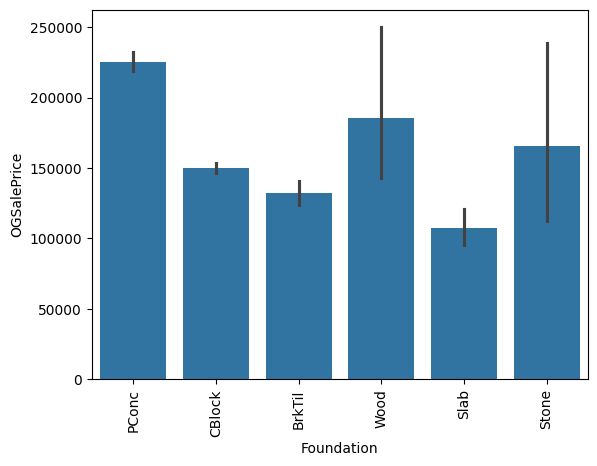

In [121]:
x_var = string_cols.columns[12]

sns.barplot(data=comb_train, x=x_var, y="OGSalePrice")
plt.xticks(rotation=90)
plt.show()

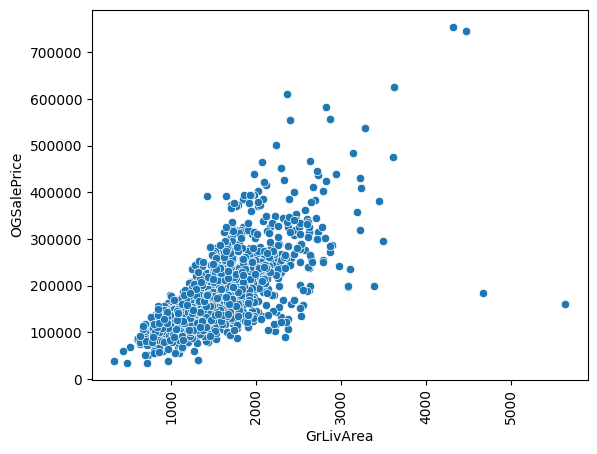

In [122]:
x_var = "GrLivArea"

# Count unique levels in the variable
n_levels = comb_train[x_var].nunique()

# Plot selection logic
if n_levels < 3:
    sns.barplot(data=comb_train, x=x_var, y="OGSalePrice")
elif n_levels < 20:
    sns.lineplot(data=comb_train, x=x_var, y="OGSalePrice")
else:
    sns.scatterplot(data=comb_train, x=x_var, y="OGSalePrice")

plt.xticks(rotation=90)
plt.show()


In [123]:
comb_train = comb_train.drop(["SalePrice", "OGSalePrice", "Dataset"], axis=1)
comb_test = comb_test.drop("Dataset", axis=1)

### Initial Modelling w CatBoost

In [124]:
categorical_cols = comb_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [125]:
categorical_cols

['MSSubClass',
 'MSZoning',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'CentralAir',
 'Electrical',
 'GarageType',
 'PavedDrive',
 'Fence',
 'YrSold',
 'SaleType',
 'SaleCondition',
 'SeasonSold',
 'MonthSold']

In [126]:
run_tune = False

final_cb_params = {
    'iterations': 10000,
    'depth': 6,
    'learning_rate': 0.01061771468785756,
    'l2_leaf_reg': 0.0018709480934528963,
    'random_strength': 1.0993239210937475,
    'bagging_temperature': 2.4073633391799016
}

def objective(trial):

    train_dir = f"catboost_cv_reg_{trial.number}"
    os.makedirs(train_dir, exist_ok=True)

    params = {
        'iterations': final_cb_params['iterations'],

        'depth': trial.suggest_int('depth',
                                   final_cb_params['depth']-1,
                                   final_cb_params['depth']+1),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            final_cb_params['learning_rate'] * 0.97,
            final_cb_params['learning_rate'] * 1.03,
            log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            final_cb_params['l2_leaf_reg'] * 0.90,
            final_cb_params['l2_leaf_reg'] * 1.10,
            log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength',
            final_cb_params['random_strength'] * 0.95,
            final_cb_params['random_strength'] * 1.05
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature',
            final_cb_params['bagging_temperature'] * 0.95,
            final_cb_params['bagging_temperature'] * 1.05
        ),

        'train_dir': train_dir,       # SAFE for parallel trials
        'allow_writing_files': False,

        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'task_type': 'CPU',
        'thread_count': 1,
        'bootstrap_type': 'Bayesian'
    }

    dataset = Pool(comb_train, y_train, cat_features=categorical_cols)

    cv_results = cv(
        params=params,
        pool=dataset,
        fold_count=5,
        seed=SEED,
        partition_random_seed=SEED,
        shuffle=True,
        verbose=False
    )

    return np.min(cv_results['test-RMSE-mean'])


if run_tune:
    study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=24, n_jobs=4)

    print("Best Score (RMSE):", study.best_value)
    print("Best Params:", study.best_params)


In [127]:
# Best HPs

final_cb_params = {'iterations': 10000, 'depth': 6, 'learning_rate': 0.01061771468785756, 'l2_leaf_reg': 0.0018709480934528963, 'random_strength': 1.0993239210937475, 'bagging_temperature': 2.4073633391799016, 'random_seed': SEED}
best_cb = CatBoostRegressor(**final_cb_params)
best_cb.fit(comb_train, y_train, cat_features=categorical_cols)

0:	learn: 0.3962844	total: 66.5ms	remaining: 11m 5s
1:	learn: 0.3932897	total: 74.5ms	remaining: 6m 12s
2:	learn: 0.3905930	total: 82.7ms	remaining: 4m 35s
3:	learn: 0.3876842	total: 96.1ms	remaining: 4m
4:	learn: 0.3850157	total: 104ms	remaining: 3m 27s
5:	learn: 0.3822039	total: 122ms	remaining: 3m 23s
6:	learn: 0.3796730	total: 130ms	remaining: 3m 5s
7:	learn: 0.3768530	total: 136ms	remaining: 2m 49s
8:	learn: 0.3741848	total: 143ms	remaining: 2m 38s
9:	learn: 0.3714813	total: 149ms	remaining: 2m 28s
10:	learn: 0.3687423	total: 155ms	remaining: 2m 20s
11:	learn: 0.3661606	total: 161ms	remaining: 2m 13s
12:	learn: 0.3635572	total: 165ms	remaining: 2m 7s
13:	learn: 0.3610138	total: 171ms	remaining: 2m 1s
14:	learn: 0.3584328	total: 176ms	remaining: 1m 57s
15:	learn: 0.3557356	total: 181ms	remaining: 1m 53s
16:	learn: 0.3532199	total: 186ms	remaining: 1m 49s
17:	learn: 0.3507893	total: 192ms	remaining: 1m 46s
18:	learn: 0.3484493	total: 198ms	remaining: 1m 43s
19:	learn: 0.3459390	tota

In [128]:
submissions_dir = Path.cwd().parent / "Submissions"
submissions_dir.mkdir(exist_ok=True)

best_cb_preds = pd.Series(best_cb.predict(comb_test))
sub_df = pd.concat([test["Id"], np.exp(best_cb_preds)], axis=1)
sub_df.columns = ["Id", "SalePrice"]
sub_df.to_csv(submissions_dir / "best_cb_sub.csv", index=False)